# Общая постановка задачи
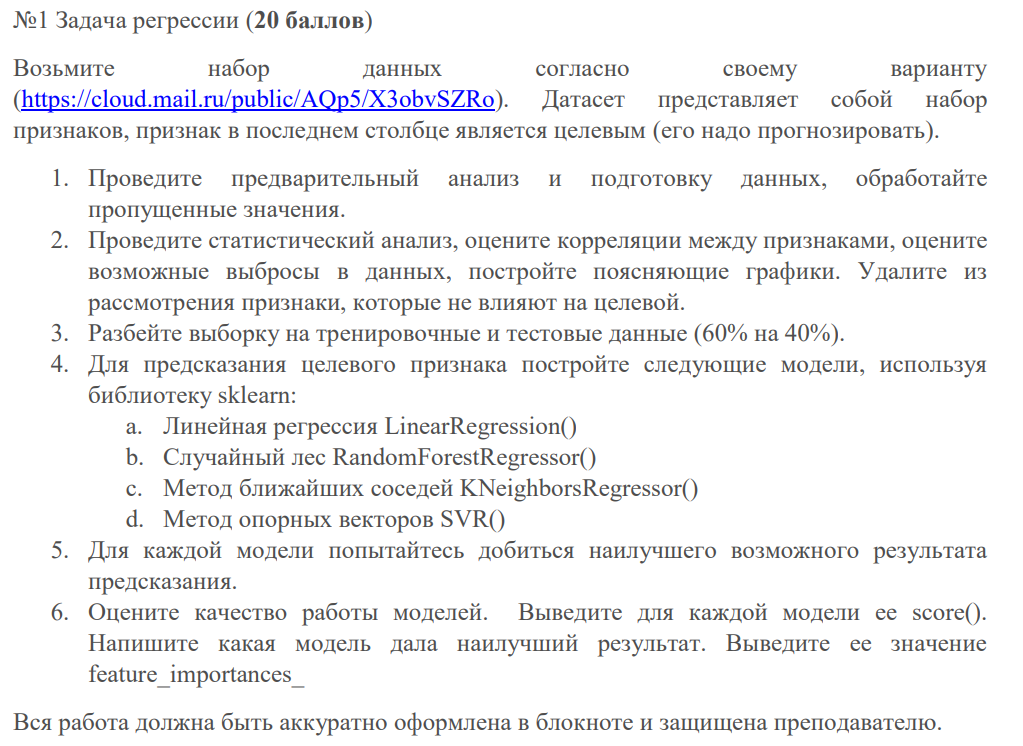

### Импорт и настройка

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

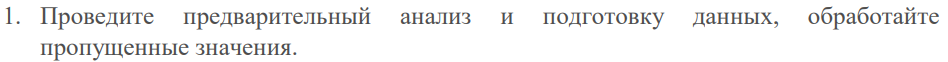

In [51]:
# Загрузка данных
df = pd.read_csv("dataset.csv", delimiter=';', header=None)

# Наименование столбцов (Feature_(0-6), Target) 
df.columns = ["F_0","F_1","F_2","F_3","F_4","F_5","F_6","Target"]

print(f"Размер набора данных: {df.shape}")
print(f"\nПервые строчки:\n{df.head()}")


Размер набора данных: (100, 8)

Первые строчки:
        F_0       F_1       F_2       F_3       F_4       F_5       F_6  \
0  0.214133 -1.235424       NaN -1.052972  1.933865 -0.842701       NaN   
1 -1.360369 -0.473853 -1.573936  0.786123 -2.539803 -0.181422  0.536506   
2 -0.121831  0.915168  0.701761  1.044884 -0.564442 -0.273393       NaN   
3 -0.114070  0.879459  0.852204  0.239273  1.049435 -1.592843       NaN   
4 -0.208355 -0.755994       NaN  0.807358 -0.313341  2.535176       NaN   

       Target  
0   13.398569  
1 -135.357118  
2   13.525125  
3   18.984126  
4  -68.970832  


In [25]:
# Общая информация о данных
print("\nИнформация о наборе данных:")
print(df.info())
print(f"\nСтатистика по признакам:\n{df.describe()}")



Информация о наборе данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F_0     100 non-null    float64
 1   F_1     100 non-null    float64
 2   F_2     95 non-null     float64
 3   F_3     100 non-null    float64
 4   F_4     100 non-null    float64
 5   F_5     100 non-null    float64
 6   F_6     30 non-null     float64
 7   Target  100 non-null    float64
dtypes: float64(8)
memory usage: 6.4 KB
None

Статистика по признакам:
              F_0         F_1        F_2         F_3         F_4         F_5  \
count  100.000000  100.000000  95.000000  100.000000  100.000000  100.000000   
mean     0.015343   -0.012940   0.228354    0.104102    0.023407    0.157920   
std      1.031383    1.036860   2.751545    0.960084    1.104505    1.089295   
min     -2.380263   -2.728176 -11.465242   -2.031232   -2.540629   -3.161702   
25%     -0.720684   -0.6648

In [49]:
# Проверка пропущенных значений
print(f"\nКоличествоп пропущенных значений:\n{df.isnull().sum()}")
print(f"\nОбщий процент пропущеных значений:\n{(df.isnull().sum().sum() / (df.size) * 100):.2f}%")


Количествоп пропущенных значений:
F_0        0
F_1        0
F_2        5
F_3        0
F_4        0
F_5        0
F_6       70
Target     0
dtype: int64

Общий процент пропущеных значений:
9.38%


In [57]:
# Обработка столбцов с пропущенными значениями
print("Удаление столбца F_6:\n")
df_cleaned = df.drop(columns=df.columns[-2])

df_filled = df_cleaned.copy()
for col in df_filled.columns:
    if df_filled[col].isnull().sum() > 0:
        median = df_filled[col].median()
        df_filled[col].fillna(median,inplace=True)
        print(f"Столбец {col} заполнен {df_cleaned[col].isnull().sum()} пропущенных значений медианой {median:.16f}")

print(f"\nПроверка:\n{df_filled.isnull().sum()}")
print(f"\nОбработанный набор данных:\n{df_filled}")

Удаление столбца F_6:

Столбец F_2 заполнен 5 пропущенных значений медианой -0.0776515039118498

Проверка:
F_0       0
F_1       0
F_2       0
F_3       0
F_4       0
F_5       0
Target    0
dtype: int64

Обработанный набор данных:
         F_0       F_1       F_2       F_3       F_4       F_5      Target
0   0.214133 -1.235424 -0.077652 -1.052972  1.933865 -0.842701   13.398569
1  -1.360369 -0.473853 -1.573936  0.786123 -2.539803 -0.181422 -135.357118
2  -0.121831  0.915168  0.701761  1.044884 -0.564442 -0.273393   13.525125
3  -0.114070  0.879459  0.852204  0.239273  1.049435 -1.592843   18.984126
4  -0.208355 -0.755994 -0.077652  0.807358 -0.313341  2.535176  -68.970832
..       ...       ...       ...       ...       ...       ...         ...
95  2.043004  0.502506  0.936901  0.142347  0.774620  0.061233  156.272314
96  0.215843  1.441745  1.291374  0.052459  1.277780  0.837371   55.739077
97  0.989703 -1.287235  0.065657 -1.099566  2.136635 -0.000078   63.254604
98 -0.839126 -0.84

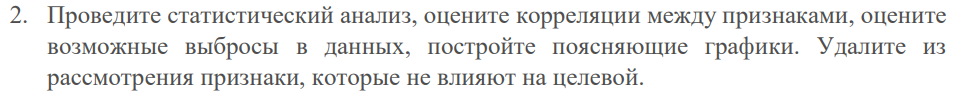

Матрица корреляций:
             F_0       F_1       F_2       F_3       F_4       F_5    Target
F_0     1.000000 -0.092111 -0.077698 -0.033009  0.144872  0.046017  0.898688
F_1    -0.092111  1.000000 -0.035308 -0.129019 -0.016449 -0.070098 -0.049786
F_2    -0.077698 -0.035308  1.000000 -0.112817  0.184886 -0.030004  0.192515
F_3    -0.033009 -0.129019 -0.112817  1.000000  0.034218 -0.020743 -0.031371
F_4     0.144872 -0.016449  0.184886  0.034218  1.000000 -0.013547  0.269431
F_5     0.046017 -0.070098 -0.030004 -0.020743 -0.013547  1.000000  0.001509
Target  0.898688 -0.049786  0.192515 -0.031371  0.269431  0.001509  1.000000

Корреляция признаков с целевым:
Target    1.000000
F_0       0.898688
F_4       0.269431
F_2       0.192515
F_5       0.001509
F_3      -0.031371
F_1      -0.049786
Name: Target, dtype: float64


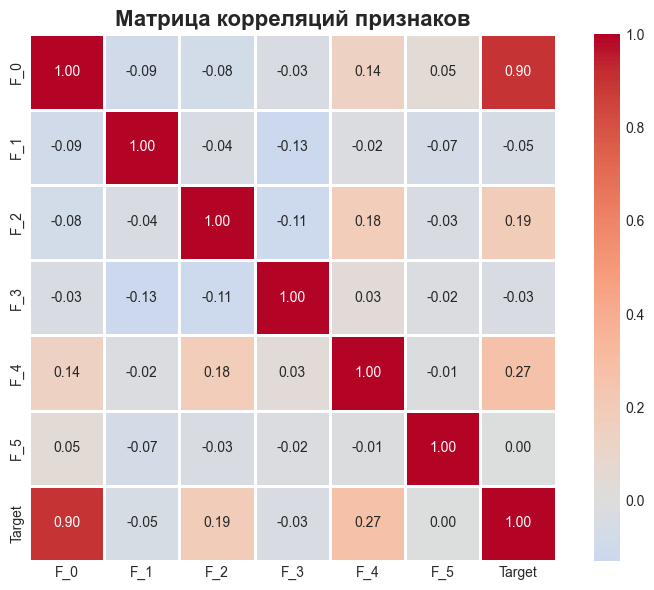

In [ ]:
# Вычисление корреляций
correl_matrix = df_filled.corr()
print(f"Матрица корреляций:\n{correl_matrix}")

target_correl = correl_matrix['Target'].sort_values(ascending=False)
print(f"\nКорреляция признаков с целевым:\n{target_correl}")

# Визуализация корреляций
plt.figure(figsize=(8,6))
sns.heatmap(correl_matrix,annot=True,cmap='coolwarm',center=0,fmt='.2f',square=True,linewidths=1)
plt.title("Матрица корреляций признаков", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

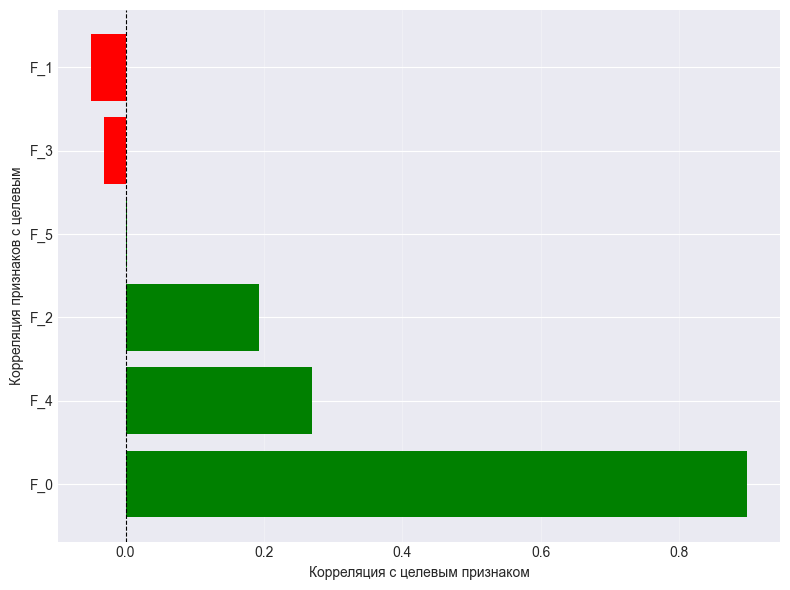

In [ ]:
# Визуализация корреляции с целевым признаком
plt.figure(figsize=(8,6))
target_corr_sorted = target_correl.drop('Target')
colors = ['green' if x > 0 else 'red' for x in target_corr_sorted]
plt.barh(target_corr_sorted.index,target_corr_sorted.values,color=colors)

plt.xlabel("Корреляция с целевым признаком")
plt.ylabel("Корреляция признаков с целевым")

plt.axvline(x=0,color='black',linestyle="--",linewidth=0.8)
plt.grid(axis='x',alpha=0.3)
plt.tight_layout()

plt.show()

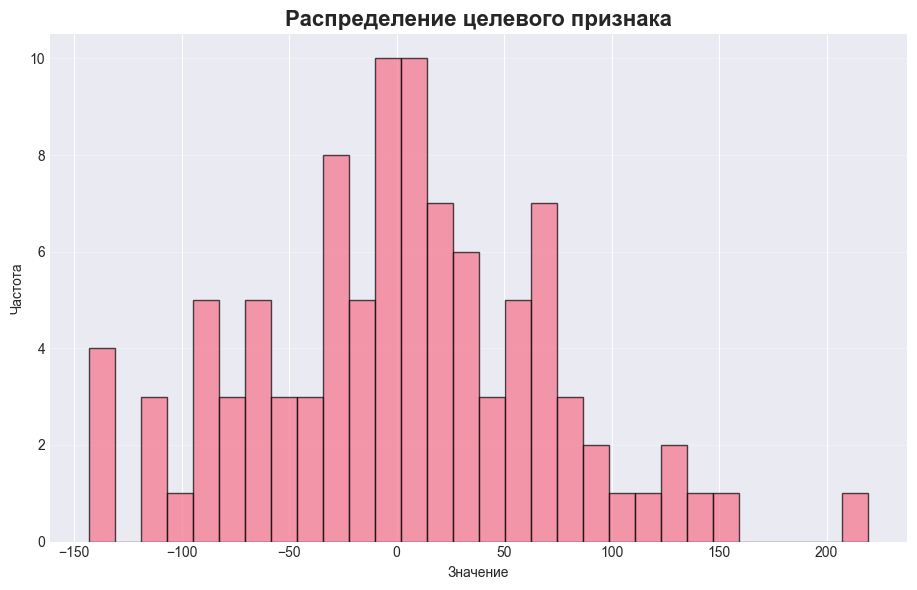

Целевые признаки: 0.79,
Медиана: 2.54,
Стд. отклонение: 69.67


In [72]:
# Распределение целевого признака
plt.figure(figsize=(18,6))
plt.subplot(1,2,1)
plt.hist(df_filled['Target'],bins=30,edgecolor='black',alpha=0.7)

plt.xlabel("Значение")
plt.ylabel("Частота")
plt.title("Распределение целевого признака", fontsize=16, fontweight='bold')

plt.grid(axis='y',alpha=0.3)
plt.tight_layout()

plt.show()

print(f"Целевые признаки: {df_filled['Target'].mean():.2f},\n"
      f"Медиана: {df_filled['Target'].median():.2f},\n"
      f"Стд. отклонение: {df_filled['Target'].std():.2f}")

In [77]:
# Определение выбросов с использование IQR
def detect_outliers_iqr(data,column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    return outliers, lower_bound, upper_bound

print("Анализ выбросов по каждому признаку:")
outliers_summary = {}
for col in df_filled.columns:
    outliers, lower, upper = detect_outliers_iqr(df_filled,col)
    outliers_summary[col] = len(outliers)
    print(f"{col}: {len(outliers)} выборос(ов) ({len(outliers)/len(df_filled) * 100:.1f}%)"
          f" Границы: {lower:.2f},{upper:.2f}")

Анализ выбросов по каждому признаку:
F_0: 1 выборос(ов) (1.0%) Границы: -2.74,2.64
F_1: 2 выборос(ов) (2.0%) Границы: -2.62,2.60
F_2: 4 выборос(ов) (4.0%) Границы: -2.62,2.72
F_3: 0 выборос(ов) (0.0%) Границы: -2.79,2.99
F_4: 0 выборос(ов) (0.0%) Границы: -2.91,3.00
F_5: 3 выборос(ов) (3.0%) Границы: -2.42,2.80
Target: 1 выборос(ов) (1.0%) Границы: -179.70,180.84


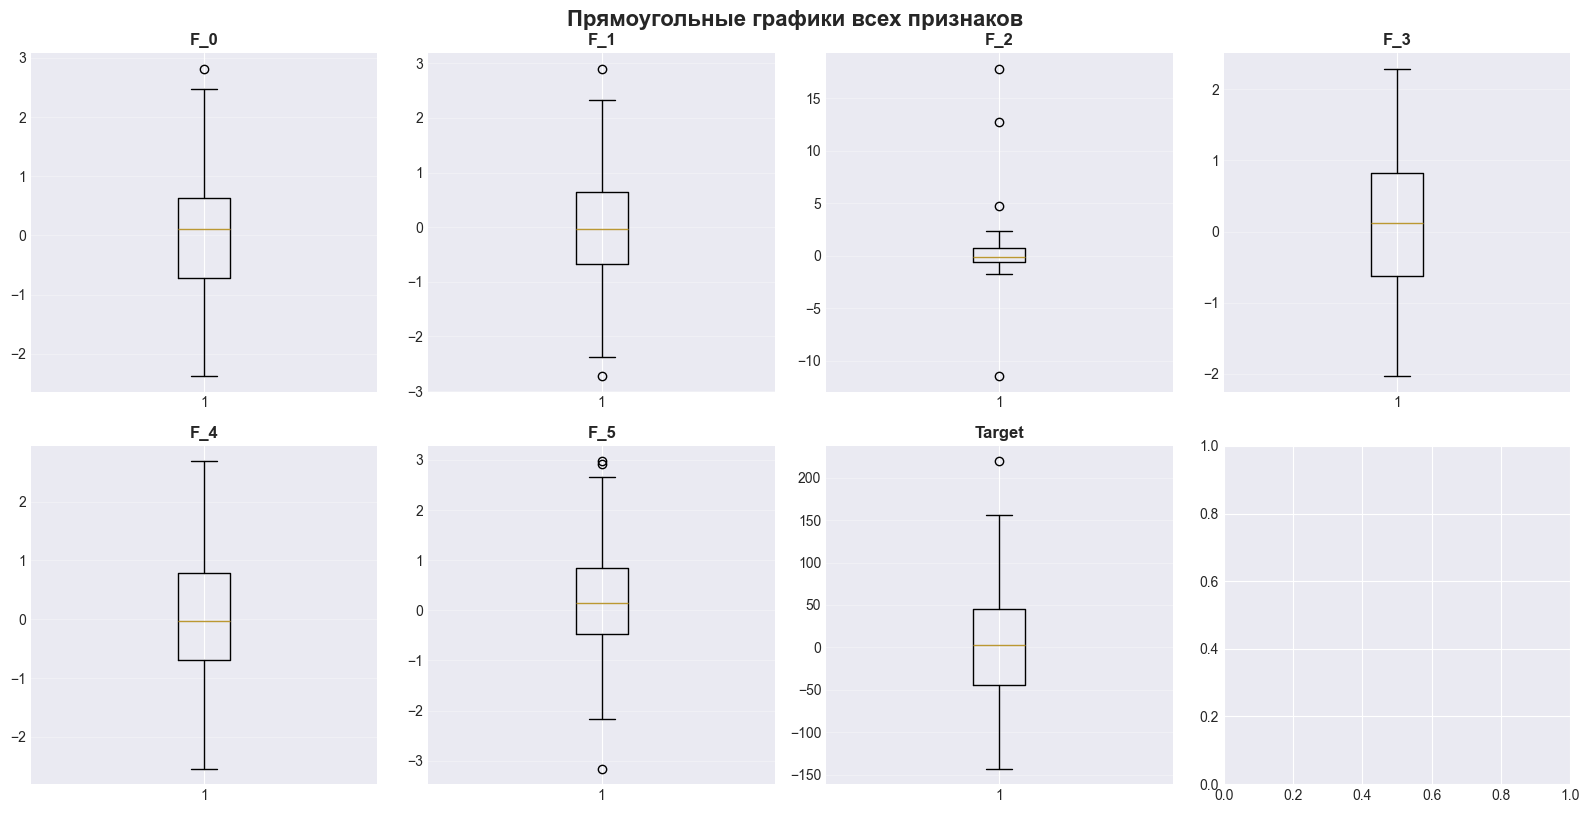

In [79]:
# Визуальное распределение всех признаков
fig, axes = plt.subplots(2,4, figsize=(16,8)) 
axes = axes.ravel()

for idx, col in enumerate(df_filled.columns):
    axes[idx].boxplot(df_filled[col],vert=True)
    axes[idx].set_title(col,fontweight='bold')
    axes[idx].grid(axis='y',alpha=0.3)
    
plt.tight_layout()
plt.suptitle("Прямоугольные графики всех признаков", fontsize=16,fontweight='bold',y=1.01)
plt.show()


In [82]:
# Отбор признаков при слабой корреляции
threshold = 0.1
weak_features = target_correl[abs(target_correl) < threshold].index.to_list()
if "Target" in weak_features:
    weak_features.remove("Target")

print(f"\nПризнаки со слабой корреляцией (|r| < {threshold}")
for feature in weak_features:
    print(f"{feature}: r = {target_correl[feature]:.4f}")
    
df_selected = df_filled.drop(columns=weak_features)
print(f"\nПризнаки после отбора: {list(df_selected.columns)}")
print(f"\nУдалено признаков: {len(weak_features)}")
print(f"\nОсталось признаков: {df_selected.shape[1] - 1} (+ целевой)")




Признаки со слабой корреляцией (|r| < 0.1
F_5: r = 0.0015
F_3: r = -0.0314
F_1: r = -0.0498

Признаки после отбора: ['F_0', 'F_2', 'F_4', 'Target']

Удалено признаков: 3

Осталось признаков: 3 (+ целевой)


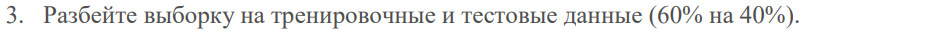

In [87]:
# Разбиение на признаки и целевую переменную
x = df_selected.drop('Target', axis=1)
y = df_selected['Target']

# Разбиение 60% тренировочные, 40% тестовые
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.4, random_state=42)

print(f"Размер обучающегй выборки: {x_train.shape[0]}, ({y_train.shape[0]/len(x)*100:.0f}%)")
print(f"Размер тестовой выборки: {x_test.shape[0]}, ({y_test.shape[0]/len(x)*100:.0f}%)")
print(f"Количество признаков: {x_train.shape[1]}")


Размер обучающегй выборки: 60, (60%)
Размер тестовой выборки: 40, (40%)
Количество признаков: 3


In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Данные масштабированы")

Данные стандартизированы для моделей, чувствительных к масштабу
